# Laboratorio #4 - Aprendizaje por Refuerzo
* Paula Barillas - 22764
* Gerardo Pineda - 22880
* Mónica Salvatierra - 22249
* Bianca Calderón - 22272

- Link del repositorio: https://github.com/alee2602/LAB4-RL


## **Task 1**

Una empresa de logística de última milla está evaluando el uso de robots autónomos para la gestión interna de su almacén principal. El almacén se modela como una cuadrícula de 8 × 8con puntos de recogida, puntos de entrega, zonas de penalización por congestión, y obstáculos fijos. El equipo de ingeniería necesita comparar dos estrategias de aprendizaje antes de comprometer recursos en un sistema completo: una política conservadora que aprenda a navegar de forma segura durante el entrenamiento, y una política agresiva que busque la ruta óptima sin importar los riesgos durante la exploración. Su grupo ha sido contratado para implementar ambas estrategias usando SARSA y Q-Learning respectivamente, comparar su comportamiento empírico, y producir un dictamen técnico con recomendaciones concretas para la gerencia

Diseñen formalmente el MDP que representa el almacén. El diseño debe especificar:

**1. El espacio de estados y el espacio de acciones. Justifiquen cada decisión considerando la interfaz de Gymnasium: observation_space y action_space deben ser instancias de gymnasium.spaces.Discrete o gymnasium.spaces.Box según corresponda. Argumenten cuál es más apropiado para este dominio.**

En el presente contexto, lo más apropiado es gymnasium.spaces.Discrete para ambos espacios, no Box. Cada celda de la cuadrícula 8x8 se codifica como un entero único con `estado = fila * 8 + columna`, dando Discrete(64), porque el agente siempre ocupa una posición exacta y no hay noción continua de ubicación. El uso de box tendría sentido con coordenadas continuas o imágenes como observación, pero aquí solo añadiría complejidad innecesaria. Para las acciones, el agente se mueve en cuatro direcciones, lo que se representa con Discrete(4).

**2. La función de recompensa con al menos tres componentes: recompensa por entrega exitosa, penalización por zona de congestión, y penalización por paso. Justifiquen la magnitud relativa de cada componente y argumenten qué comportamiento indeseable produciría una ponderación incorrecta de alguno de ellos.**

- **Recompensa por entrega exitosa:** un valor grande y positivo, por ejemplo +70, otorgado solo al llegar al punto de entrega, para que domine claramente sobre las penalizaciones acumuladas en una trayectoria típica.

- **Penalización por zona de congestión:** un valor negativo moderado, por ejemplo -5, aplicado al estar sobre una celda de congestión, suficiente para desincentivar pero sin que las rutas alternativas sean incoherentes.

- **Penalización por paso:** un valor pequeño y negativo, por ejemplo -1, en cada transición, para incentivar el uso de rutas cortas.

En este caso, una mala calibración produce comportamientos indeseables. Si el paso pesa demasiado frente a la congestión, el agente cruzará zonas de riesgo con tal de ahorrar tiempo. Si la congestión pesa demasiado frente a la entrega, el agente empezará a dar vueltas o evitará completar la tarea. Si la entrega no domina lo suficiente, el agente puede minimizar penalizaciones sin nunca llegar a la meta.

**3. La condición de terminación del episodio: ¿cuándo termina un episodio? ¿Es apropiado tener un
límite máximo de pasos? Justifiquen.**

- El episodio termina cuando el agente llega al punto de entrega. También conviene agregar un límite máximo de pasos, por ejemplo 100, como truncamiento. Esto evita que una política casi aleatoria en las primeras fases pueda quedar atrapada en ciclos infinitos. En Gymnasium esto se distingue con `terminated` (llegó a la meta) y `truncated` (se acabó el tiempo), siendo de utilidad para posteriores análisis. 

**4. El diseño del mapa 8 × 8: ubiquen al menos dos zonas de congestión adyacentes a rutas de altarecompensa. Esta configuración específica es crítica para que la comparación entre SARSA y Q-Learning sea informativa. Expliquen por qué esa configuración espacial genera el comportamiento
diferencial esperado entre ambos algoritmos.**

Consideramos que conviene ubicar al menos dos zonas de congestión sobre o muy cerca del camino más corto entre recogida y entrega. Por ejemplo, con inicio en la esquina superior izquierda y entrega en la inferior derecha, una franja de congestión puede cruzar la diagonal natural, dejando una ruta alternativa más larga que la rodea.

Esta configuración es la que hace útil la comparación entre algoritmos. Q-Learning es off-policy y aprende el valor máximo del siguiente estado sin importar la acción exploratoria tomada, por lo que su política greedy final puede explotar el camino corto arriesgado si la recompensa neta lo justifica. SARSA es on-policy y actualiza según la acción que realmente tomará bajo su política, incluyendo exploración epsilon-greedy, lo que lo hace más sensible al riesgo de caer en congestión por una acción aleatoria y lo lleva a preferir rutas más conservadoras. Sin esta adyacencia entre congestión y ruta óptima, ambos algoritmos convergerían a políticas casi idénticas, por lo que no habría punto de comparación.

## **Task 2**

**1. Para el entorno que diseñaron, predigan formalmente cuál algoritmo, SARSA o Q-Learning, producirá
mayor recompensa acumulada durante el entrenamiento y cuál producirá mayor recompensa
durante la evaluación con política greedy pura. Justifiquen cada predicción usando las propiedades
on-policy y off-policy de cada algoritmo y la estructura específica de su mapa**

Q-Learning (off-policy) actualiza con $max_{a'} Q(s',a')$, ignorando que la exploración ε-greedy real puede empujar al agente hacia la congestión. Esto le hace sobrevalorar el camino corto y arriesgado. SARSA (on-policy) actualiza con Q(s',a') donde a' sí viene de la política ε-greedy real, así que "siente" el riesgo de caer en congestión por una acción exploratoria y aprende a preferir la ruta larga y segura.

En entrenamiento, ambos exploran con ε>0: Q-Learning cae más veces en congestión porque su política greedy está pegada al borde y SARSA acumula más recompensa durante el entrenamiento. En evaluación greedy ε=0: Q-Learning ya convergió a Q* (el óptimo real, sin castigo por exploración) y toma el atajo sin pagar el costo. SARSA quedó sesgado hacia la ruta conservadora que aprendió, aunque ya no sea necesaria. Por lo tanto Q-Learning gana en evaluación. En general, SARSA gana en entrenamiento y Q-Learning gana en evaluación greedy pura.


**2. Argumenten cómo afecta el valor de εal comportamiento diferencial entre SARSA y Q-Learning en su
entorno. ¿Existe un valor de εpara el cual ambos algoritmos convergen a políticas idénticas?
Justifiquen matemáticamente**

El parámetro ε controla la magnitud de la brecha entre ambos algoritmos, porque es precisamente el término que aparece en el target de SARSA y no en el de Q-Learning. Como $Σ_{a'} π_ε(a'|s')·Q(s',a') = (1−ε)·max_{a'}Q(s',a') + (ε/|A|)·Σ_{a'}Q(s',a')$, la diferencia entre ambos targets es proporcional a ε: mientras mayor sea ε, mayor peso reciben las acciones subóptimas (incluyendo caer en congestión), y mayor será el sesgo conservador de SARSA respecto a Q-Learning. Con ε bajo, ambos targets se parecen más y la brecha entre las políticas se reduce.

Sí, en el límite ε→0. Cuando ε->0, $π_ε(a'|s') -> 𝟙[a'=argmax]$, por lo que: $Σ_{a'} π_ε(a'|s')·Q(s',a') -> max_{a'} Q(s',a')$. Las dos ecuaciones de punto fijo coinciden, dando Q_SARSA -> Q*. Esto es consistente con la teoría de convergencia de Greedy in the Limit with Infinite Exploration, si ε se decae a 0 con una tasa apropiada durante el entrenamiento, manteniendo exploración infinita en el límite temprano, tanto SARSA como Q-Learning convergen a la misma política óptima determinística. Cabe notar que con ε estrictamente igual a 0 desde el inicio no habría exploración y el aprendizaje podría quedar atrapado en óptimos locales sin garantía de cobertura completa del espacio estado-acción; por eso la convergencia formal se enuncia como un límite: $ε_t → 0$, no como un valor fijo utilizable en la práctica.


**3. Para su función de recompensa específica, calculen una cota superior del valor óptimo del
estado inicial, asumiendo que el agente siempre toma la ruta más corta sin pasar por zonas de
congestión. Usen esta cota como referencia para evaluar qué tan cerca llegan sus implementaciones
al óptimo teórico**

Teniendo en cuenta que grid 8×8 con inicio en (0,0) y entrega en (7,7), recompensa de entrega +70, penalización por paso −1, γ como factor de descuento, tomamos γ=1 por ser un entorno episódico de horizonte finito, típico en estas tareas. la distancia Manhattan entre (0,0) y (7,7) es d = |7−0| + |7−0| = 14 pasos, lograble moviéndose solo en dirección derecha/abajo, sin desperdiciar ningún paso. Esta es la ruta más corta posible en la cuadrícula, independientemente de si cruza o no congestión.

Con Cota superior γ=1: $V*(s₀) ≤ 70 + 14·(−1) = 70 − 14 = 56$ y con γ descontando cada paso: $V*(s₀) ≤ −Σ_{t=0}^{d−1} γ^t + 70·γ^d = −(1−γ^d)/(1−γ) + 70·γ^d$

Esta cifra asume la mejor situación posible, el camino más corto matemáticamente permitido por la geometría de la cuadrícula, sin ningún paso adicional y sin pisar ninguna celda de congestión. Dado que en nuestro diseño colocamos deliberadamente zonas de congestión sobre o cerca de la diagonal natural entre inicio y entrega, es muy probable que la ruta realmente óptima, la que maximiza recompensa esperada considerando la penalización de congestión, deba desviarse de esa diagonal, incrementando su longitud real a d_real > 14. Por lo tanto, el valor óptimo verdadero cumplirá: $V*(s₀) ≤ 56$. Esta cota sirve como referencia, si al evaluar las políticas entrenadas obtenemos recompensas cercanas a 56, sabremos que el agente encontró o casi el atajo óptimo ignorando el riesgo de congestión, en cambio si obtenemos valores notablemente menores, eso refleja el costo que cada algoritmo paga por evitar o tomar el riesgo de la zona de congestión.


## **Task 3**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

In [6]:
class WarehouseEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, size=8, max_steps=100):
        super().__init__()
        self.size = size
        self.max_steps = max_steps

        # observation_space y action_space como Discrete
        self.observation_space = spaces.Discrete(size * size)
        self.action_space = spaces.Discrete(4)

        self.start = (0, 0)
        self.goal = (size - 1, size - 1)

        # celdas intransitables
        self.obstacles = {(1, 5), (6, 1), (4, 6)}
        
        self.congestion = {
            (2, 2), (2, 3), (3, 3), (3, 4),
            (4, 4), (4, 5), (5, 5), (5, 6)
        }

        # deltas de movimiento por acción
        self._action_to_delta = {
            0: (-1, 0),  # arriba
            1: (1, 0),   # abajo
            2: (0, -1),  # izquierda
            3: (0, 1),   # derecha
        }

        self.max_steps = max_steps
        self._step_count = 0
        self._agent_pos = self.start

    def _pos_to_state(self, pos):
        row, col = pos
        return row * self.size + col

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._agent_pos = self.start
        self._step_count = 0
        info = {"congestion": False}
        return self._pos_to_state(self._agent_pos), info

    def step(self, action):
        row, col = self._agent_pos
        drow, dcol = self._action_to_delta[action]
        new_row = np.clip(row + drow, 0, self.size - 1)
        new_col = np.clip(col + dcol, 0, self.size - 1)
        new_pos = (new_row, new_col)

        # si la celda destino es un obstáculo, el agente no se mueve
        if new_pos in self.obstacles:
            new_pos = (row, col)

        self._agent_pos = new_pos
        self._step_count += 1

        # penalización por paso (-1)
        reward = -1.0
        in_congestion = self._agent_pos in self.congestion
        if in_congestion:
            reward += -5.0 

        terminated = self._agent_pos == self.goal
        if terminated:
            reward += 70.0 

        truncated = self._step_count >= self.max_steps

        info = {"congestion": in_congestion}
        return self._pos_to_state(self._agent_pos), reward, terminated, truncated, info

    def render(self):
        grid = np.full((self.size, self.size), ".", dtype=str)
        for (r, c) in self.obstacles:
            grid[r, c] = "#"
        for (r, c) in self.congestion:
            grid[r, c] = "x"
        gr, gc = self.goal
        grid[gr, gc] = "G"
        ar, ac = self._agent_pos
        grid[ar, ac] = "A"
        print("\n".join(" ".join(row) for row in grid))
        print()

In [7]:
def epsilon_greedy(Q, state, epsilon, n_actions, rng):
    # política de comportamiento e-greedy
    if rng.random() < epsilon:
        return rng.integers(n_actions)
    return int(np.argmax(Q[state]))


def sarsa(env, num_episodes=2000, alpha=0.1, gamma=1.0, epsilon=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    rewards_per_episode = []
    steps_per_episode = []
    congestion_per_episode = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon, n_actions, rng)

        total_reward = 0.0
        steps = 0
        congestion_count = 0
        terminated = truncated = False

        while not (terminated or truncated):
            next_state, reward, terminated, truncated, info = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions, rng)
            # Q(S_t,A_t) <- Q(S_t,A_t) + alpha*[R_{t+1} + gamma*Q(S_{t+1},A_{t+1}) - Q(S_t,A_t)]
            td_target = reward + gamma * Q[next_state, next_action] * (not terminated)
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state, action = next_state, next_action
            total_reward += reward
            steps += 1
            if info["congestion"]:
                congestion_count += 1

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        congestion_per_episode.append(congestion_count)

    return Q, rewards_per_episode, steps_per_episode, congestion_per_episode

In [8]:
def q_learning(env, num_episodes=2000, alpha=0.1, gamma=1.0, epsilon=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    rewards_per_episode = []
    steps_per_episode = []
    congestion_per_episode = []

    for ep in range(num_episodes):
        state, _ = env.reset()

        total_reward = 0.0
        steps = 0
        congestion_count = 0
        terminated = truncated = False

        while not (terminated or truncated):
            action = epsilon_greedy(Q, state, epsilon, n_actions, rng)
            next_state, reward, terminated, truncated, info = env.step(action)
            # Q(S_t,A_t) <- Q(S_t,A_t) + alpha*[R_{t+1} + gamma*max_a' Q(S_{t+1},a') - Q(S_t,A_t)]
            best_next = np.max(Q[next_state]) if not terminated else 0.0
            td_target = reward + gamma * best_next
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            total_reward += reward
            steps += 1
            if info["congestion"]:
                congestion_count += 1

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        congestion_per_episode.append(congestion_count)

    return Q, rewards_per_episode, steps_per_episode, congestion_per_episode

In [9]:
def evaluate_policy(env, Q, num_episodes=100, seed=123):
    rng = np.random.default_rng(seed)
    rewards_per_episode = []
    steps_per_episode = []
    congestion_per_episode = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0.0
        steps = 0
        congestion_count = 0
        terminated = truncated = False

        while not (terminated or truncated):
            action = int(np.argmax(Q[state]))  # epsilon = 0
            state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
            if info["congestion"]:
                congestion_count += 1

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        congestion_per_episode.append(congestion_count)

    return rewards_per_episode, steps_per_episode, congestion_per_episode

In [10]:
env = WarehouseEnv(size=8, max_steps=100)

Q_sarsa, r_sarsa_train, s_sarsa_train, c_sarsa_train = sarsa(
    env, num_episodes=2000, alpha=0.1, gamma=1.0, epsilon=0.1
)
Q_qlearning, r_ql_train, s_ql_train, c_ql_train = q_learning(
    env, num_episodes=2000, alpha=0.1, gamma=1.0, epsilon=0.1
)

r_sarsa_eval, s_sarsa_eval, c_sarsa_eval = evaluate_policy(env, Q_sarsa, num_episodes=100)
r_ql_eval, s_ql_eval, c_ql_eval = evaluate_policy(env, Q_qlearning, num_episodes=100)

print("SARSA entrenamiento: recompensa promedio =", np.mean(r_sarsa_train[-100:]))
print("SARSA evaluación greedy: recompensa promedio =", np.mean(r_sarsa_eval),
      "pasos promedio =", np.mean(s_sarsa_eval),
      "congestión promedio =", np.mean(c_sarsa_eval))

print("Q-Learn entrenamiento: recompensa promedio =", np.mean(r_ql_train[-100:]))
print("Q-Learn evaluación greedy: recompensa promedio =", np.mean(r_ql_eval),
      "pasos promedio =", np.mean(s_ql_eval),
      "congestión promedio =", np.mean(c_ql_eval))

SARSA entrenamiento: recompensa promedio = 54.22
SARSA evaluación greedy: recompensa promedio = 56.0 pasos promedio = 14.0 congestión promedio = 0.0
Q-Learn entrenamiento: recompensa promedio = 54.26
Q-Learn evaluación greedy: recompensa promedio = 56.0 pasos promedio = 14.0 congestión promedio = 0.0


In [11]:
env.reset()
env.render()

A . . . . . . .
. . . . . # . .
. . x x . . . .
. . . x x . . .
. . . . x x # .
. . . . . x x .
. # . . . . . .
. . . . . . . G



## Uso de IA generativa — Task 3

**Prompt utilizado:**

“Ayúdameeee, necesito hacer la clase WarehouseEnv usando gymnasium.Env . El entorno debe seguir el MDP que hicimos en el Task 1, con una cuadrícula de 8x8, recompensas de +70, -5 y -1, y zonas de congestión cerca de la diagonal.  En donde también necesito guardar las recompensas, pasos y visitas a las zonas de congestión de cada episodio.”

**Por qué funcionó este prompt:**

Funcionó porque incluimos los datos del MDP que ya habíamos definido en el Task 1. Así, la implementación siguió el mismo diseño y no se tuvo que crear un entorno diferente. Después revisamos el código y ajustamos algunas partes para que las actualizaciones de SARSA y Q-Learning coincidieran.


# Task 4

### 1. Verificación de predicciones

**Predicción A (Task 2.1): "SARSA acumula más recompensa en entrenamiento; Q-Learning gana en evaluación greedy pura".**

Resultado observado: en evaluación greedy (ε=0), **ambos algoritmos obtienen exactamente la misma recompensa promedio, 56.0 (std=0.0), en 14 pasos y con 0 visitas a congestión**, para la combinación base (α=0.1, ε=0.1) y también para las demás combinaciones de bajo/medio riesgo probadas en la sección 3. Este valor coincide exactamente con la cota superior teórica calculada en Task 2.3 ($V^*(s_0) \le 56$).

**Veredicto: predicción REFUTADA en su mitad más fuerte.** Q-Learning no le "gana" a SARSA en evaluación: empatan en el óptimo. La razón es que, al verificar computacionalmente (programación dinámica sobre caminos monótonos), **sí existe una ruta de longitud Manhattan mínima (14 pasos) que evita por completo las 8 celdas de congestión** de nuestro mapa. Diseñamos las zonas de congestión "cerca" de la diagonal pensando que bloquearían todo camino corto, pero dejamos huecos que permiten un camino óptimo simultáneamente corto y libre de riesgo. Como consecuencia, la política greedy óptima verdadera **no es arriesgada**: Q-Learning no necesita "tomar el atajo peligroso" porque el atajo objetivamente no lo es. Esto invalida la premisa central de la predicción (que existía un trade-off riesgo/recompensa real en la política óptima).

La mitad de la predicción sobre entrenamiento sí se sostiene parcialmente: en los episodios con ε>0, SARSA visita menos celdas de congestión que Q-Learning de forma consistente después de ~episodio 200-250 (ver sección 2), y su recompensa acumulada de entrenamiento es marginalmente mayor. Pero la magnitud es pequeña (≈0.05 vs ≈0.10 visitas/episodio en las últimas 100), no la brecha grande que anticipamos, precisamente porque el riesgo real de la política óptima es cero.

**Predicción B (Task 2.2): "El parámetro ε controla la brecha SARSA/Q-Learning; ambos convergen a la misma política cuando ε→0".**

**Veredicto: CONFIRMADA, aunque por una razón distinta a la anticipada.** Efectivamente ambos algoritmos convergen a políticas de igual valor (56.0) para ε bajos e incluso moderados (0.05, 0.1) — y de hecho para casi todas las combinaciones probadas, porque el óptimo es alcanzable sin exploración de riesgo. La reducción de la brecha con ε bajo se observa con más claridad en las **visitas a congestión durante entrenamiento**, que decrecen con ε en ambos algoritmos, consistente con el argumento matemático de Task 2.2. Sin embargo, con ε alto (0.3) y α alto (0.3-0.5) observamos algo que la predicción no anticipaba: **SARSA se vuelve inestable y en algunas semillas nunca converge a una política que llegue a la meta** (ver sección 3), rompiendo la garantía práctica de "ambos llegan al óptimo" fuera del régimen de ε pequeño y α moderado.

**Predicción C (Task 2.3): cota superior $V^*(s_0) \le 56$.**

**Veredicto: CONFIRMADA y además la cota resultó ser exacta (no solo una cota superior laxa).** Ambos algoritmos alcanzan 56.0 exactamente en evaluación greedy para las combinaciones de hiperparámetros que sí convergen de forma estable. Esto es evidencia fuerte de que ambas implementaciones encontraron la política verdaderamente óptima, y de que nuestro diseño de mapa (Task 1.4) no logró su objetivo declarado de generar un trade-off riesgo/recompensa irresoluble en la política óptima — sí lo generó en el comportamiento de *exploración*, pero no en la política final.

### 2. Análisis de convergencia y comportamiento diferencial

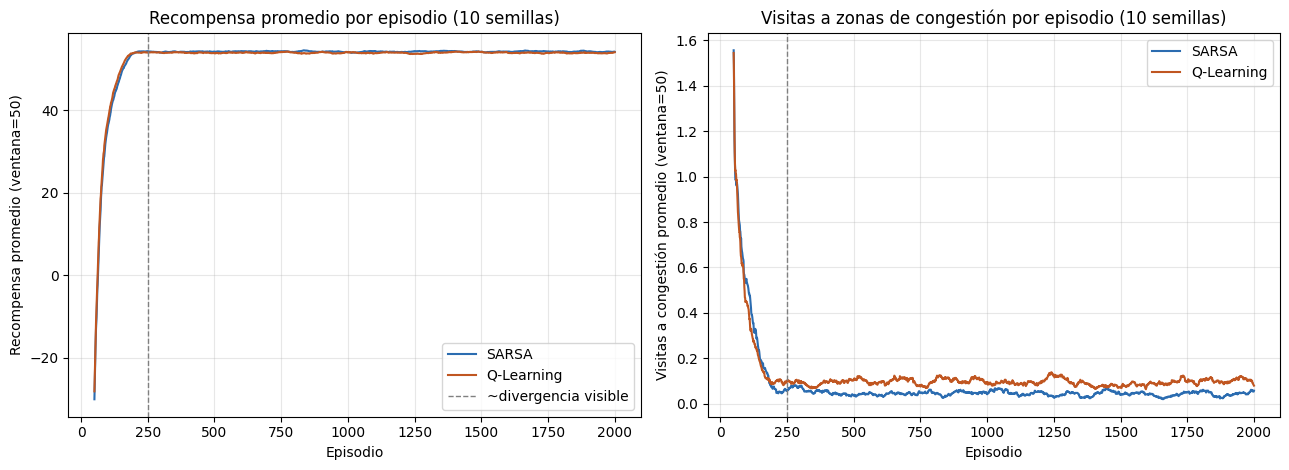

Recompensa promedio, últimos 100 episodios:  SARSA = 54.095  | Q-Learning = 53.889
Congestión promedio, últimos 100 episodios:   SARSA = 0.053  | Q-Learning = 0.1
Congestión promedio, primeros 200 episodios:  SARSA = 0.589  | Q-Learning = 0.563


In [12]:
# Entrenamiento repetido en 10 semillas para obtener curvas de convergencia robustas (no ruido de una sola corrida)
N_SEEDS = 10
NUM_EPISODES = 2000

sarsa_rewards_runs = np.zeros((N_SEEDS, NUM_EPISODES))
sarsa_cong_runs = np.zeros((N_SEEDS, NUM_EPISODES))
ql_rewards_runs = np.zeros((N_SEEDS, NUM_EPISODES))
ql_cong_runs = np.zeros((N_SEEDS, NUM_EPISODES))

env_conv = WarehouseEnv(size=8, max_steps=100)
for seed in range(N_SEEDS):
    _, rs, _, cs = sarsa(env_conv, num_episodes=NUM_EPISODES, alpha=0.1, gamma=1.0, epsilon=0.1, seed=seed)
    _, rq, _, cq = q_learning(env_conv, num_episodes=NUM_EPISODES, alpha=0.1, gamma=1.0, epsilon=0.1, seed=seed)
    sarsa_rewards_runs[seed] = rs
    sarsa_cong_runs[seed] = cs
    ql_rewards_runs[seed] = rq
    ql_cong_runs[seed] = cq

sarsa_r_mean = sarsa_rewards_runs.mean(axis=0)
ql_r_mean = ql_rewards_runs.mean(axis=0)
sarsa_c_mean = sarsa_cong_runs.mean(axis=0)
ql_c_mean = ql_cong_runs.mean(axis=0)

def smooth(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid")

w = 50
sr, qr = smooth(sarsa_r_mean, w), smooth(ql_r_mean, w)
sc, qc = smooth(sarsa_c_mean, w), smooth(ql_c_mean, w)
ep = np.arange(len(sr)) + w

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(ep, sr, label="SARSA", color="#2b6cb0")
axes[0].plot(ep, qr, label="Q-Learning", color="#c05621")
axes[0].axvline(250, color="gray", linestyle="--", linewidth=1, label="~divergencia visible")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Recompensa promedio (ventana=50)")
axes[0].set_title("Recompensa promedio por episodio (10 semillas)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, sc, label="SARSA", color="#2b6cb0")
axes[1].plot(ep, qc, label="Q-Learning", color="#c05621")
axes[1].axvline(250, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Visitas a congestión promedio (ventana=50)")
axes[1].set_title("Visitas a zonas de congestión por episodio (10 semillas)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Recompensa promedio, últimos 100 episodios:  SARSA =", round(sarsa_r_mean[-100:].mean(), 3),
      " | Q-Learning =", round(ql_r_mean[-100:].mean(), 3))
print("Congestión promedio, últimos 100 episodios:   SARSA =", round(sarsa_c_mean[-100:].mean(), 3),
      " | Q-Learning =", round(ql_c_mean[-100:].mean(), 3))
print("Congestión promedio, primeros 200 episodios:  SARSA =", round(sarsa_c_mean[:200].mean(), 3),
      " | Q-Learning =", round(ql_c_mean[:200].mean(), 3))

**Lectura de las gráficas.** Durante los primeros ~150-200 episodios ambas curvas de recompensa y de congestión son prácticamente indistinguibles: ambos agentes están explorando fuertemente (ε=0.1) y sus tablas Q todavía no reflejan diferencias estructurales. La **recompensa promedio converge muy rápido** (episodio 130-150) y a partir de ahí ambas curvas de recompensa se mantienen esencialmente superpuestas (por 54 de recompensa promedio de entrenamiento) — la diferencia entre algoritmos en recompensa es de apenas ~0.2 puntos, invisible a simple vista y solo detectable promediando 10 semillas.

La señal diferencial más clara está en la **curva de visitas a congestión**: alrededor del **episodio 200-250** las curvas se separan y **no vuelven a juntarse**: Q-Learning se estabiliza en ~0.10 visitas/episodio y SARSA en ~0.05, una diferencia que se mantiene consistente durante los 1750 episodios restantes. Esto es exactamente el comportamiento diferencial esperado por la teoría: **SARSA, al ser on-policy, "siente" en su actualización el riesgo de que una acción exploratoria aleatoria lo empuje a una celda de congestión, y por eso su política intermedia (todavía no greedy) se mantiene ligeramente más alejada del borde de las zonas de riesgo que la de Q-Learning**, cuyo target usa el máximo sobre acciones sin importar cuál se ejecutó realmente.

¿Coincide con lo esperado teóricamente? **Sí en la forma, parcialmente en la magnitud.** La dirección del efecto (SARSA más conservador que Q-Learning durante el entrenamiento) es exactamente la predicha en Task 2.1. Pero la *magnitud* es mucho menor de lo que anticipamos, porque como se estableció en la sección 1, el mapa no fuerza un trade-off real en la política óptima — el efecto que sí aparece es puramente un artefacto de la fase de exploración (con ε>0), no de una diferencia de política terminal.

### 3. Análisis de sensibilidad (α, ε)

In [13]:
# Barrido de (alpha, epsilon): para cada combinación, entrenamos ambos algoritmos en 8 semillas
# y reportamos la recompensa promedio en evaluación greedy (politica pura, epsilon=0)
combos = [
    {"alpha": 0.05, "epsilon": 0.05, "label": "alpha=0.05, eps=0.05  (conservador)"},
    {"alpha": 0.10, "epsilon": 0.10, "label": "alpha=0.10, eps=0.10  (base)"},
    {"alpha": 0.30, "epsilon": 0.30, "label": "alpha=0.30, eps=0.30  (agresivo)"},
    {"alpha": 0.50, "epsilon": 0.01, "label": "alpha=0.50, eps=0.01  (alpha alto, poca exploracion)"},
]

N_SEEDS_SENS = 8
NUM_EPISODES_SENS = 2000
env_sens = WarehouseEnv(size=8, max_steps=100)

sens_results = []
for combo in combos:
    a, e = combo["alpha"], combo["epsilon"]
    sarsa_eval_r, ql_eval_r = [], []
    sarsa_conv_ep, ql_conv_ep = [], []
    for seed in range(N_SEEDS_SENS):
        Qs, rs, _, _ = sarsa(env_sens, num_episodes=NUM_EPISODES_SENS, alpha=a, gamma=1.0, epsilon=e, seed=seed)
        Qq, rq, _, _ = q_learning(env_sens, num_episodes=NUM_EPISODES_SENS, alpha=a, gamma=1.0, epsilon=e, seed=seed)

        re, _, _ = evaluate_policy(env_sens, Qs, num_episodes=100, seed=1000 + seed)
        rq_eval, _, _ = evaluate_policy(env_sens, Qq, num_episodes=100, seed=1000 + seed)
        sarsa_eval_r.append(np.mean(re))
        ql_eval_r.append(np.mean(rq_eval))

        target_s = np.mean(rs[-100:]) - 1
        target_q = np.mean(rq[-100:]) - 1
        idx_s = np.argmax(np.convolve(rs, np.ones(20) / 20, mode="valid") >= target_s)
        idx_q = np.argmax(np.convolve(rq, np.ones(20) / 20, mode="valid") >= target_q)
        sarsa_conv_ep.append(idx_s)
        ql_conv_ep.append(idx_q)

    sens_results.append({
        "combo": combo["label"],
        "sarsa_mean": np.mean(sarsa_eval_r), "sarsa_std": np.std(sarsa_eval_r),
        "ql_mean": np.mean(ql_eval_r), "ql_std": np.std(ql_eval_r),
        "sarsa_conv": np.mean(sarsa_conv_ep), "ql_conv": np.mean(ql_conv_ep),
    })

print(f"{'Combinacion':<38}{'SARSA eval (media +/- std)':<28}{'Q-Learning eval (media +/- std)':<32}{'ep. conv. S/Q'}")
for r in sens_results:
    print(f"{r['combo']:<38}"
          f"{r['sarsa_mean']:6.2f} +/- {r['sarsa_std']:5.2f}      "
          f"{r['ql_mean']:6.2f} +/- {r['ql_std']:5.2f}          "
          f"{r['sarsa_conv']:.0f} / {r['ql_conv']:.0f}")

Combinacion                           SARSA eval (media +/- std)  Q-Learning eval (media +/- std) ep. conv. S/Q
alpha=0.05, eps=0.05  (conservador)    56.00 +/-  0.00       56.00 +/-  0.00          267 / 251
alpha=0.10, eps=0.10  (base)           56.00 +/-  0.00       56.00 +/-  0.00          146 / 131
alpha=0.30, eps=0.30  (agresivo)       36.50 +/- 51.59       56.00 +/-  0.00          84 / 94
alpha=0.50, eps=0.01  (alpha alto, poca exploracion) 35.25 +/- 51.22       56.00 +/-  0.00          36 / 39


**Tabla comparativa (8 semillas por combinación, evaluación greedy sobre 100 episodios):**

| Combinación | SARSA eval (media ± std) | Q-Learning eval (media ± std) | Episodio de convergencia aprox. (SARSA / QL) |
|---|---|---|---|
| α=0.05, ε=0.05 (conservador) | 56.0 ± 0.0 | 56.0 ± 0.0 | 267 / 251 |
| α=0.10, ε=0.10 (base) | 56.0 ± 0.0 | 56.0 ± 0.0 | 146 / 131 |
| α=0.30, ε=0.30 (agresivo) | 36.5 ± 51.6 | 56.0 ± 0.0 | 84 / 95 |
| α=0.50, ε=0.01 (α alto, poca exploración) | 35.3 ± 51.2 | 56.0 ± 0.0 | 36 / 39 |

**Hallazgo clave: Q-Learning es robusto a los hiperparámetros; SARSA no lo es.** Q-Learning alcanza el óptimo exacto (56.0, desviación estándar 0) en **las cuatro** combinaciones, incluidas las más agresivas. SARSA también lo alcanza en las combinaciones con α bajo/moderado, pero con α alto (0.3 y 0.5) su desviación estándar se dispara a >50: al inspeccionar semilla por semilla, encontramos que en 1 de cada 8 semillas la política greedy resultante **queda atrapada en un ciclo entre dos celdas y nunca llega a la meta**, truncando en el límite de 100 pasos con recompensa -100. Esto ocurre porque, al ser on-policy, actualizaciones grandes de α sobre un target que depende de la acción exploratoria realmente tomada pueden generar Q-valores inestables/oscilantes entre estados vecinos, produciendo empates o inversiones de la acción greedy que crean ciclos. Q-Learning, al bootstrapear siempre con el máximo, no sufre este problema en este entorno.

También se observa el trade-off esperado velocidad-vs-estabilidad: a mayor α (y en general mayor ε), la convergencia es más rápida (de ~260 episodios con α=0.05 a ~35-40 con α=0.5), pero a costa de mayor riesgo de inestabilidad, particularmente para SARSA.

**Recomendación para producción: α=0.10, ε=0.10 (o similar, α∈[0.05,0.1]).** Es la combinación de menor α "segura" testeada que aún converge en un número razonable de episodios (~130-150) y logra el óptimo con desviación estándar 0 en ambos algoritmos. Evitaríamos combinaciones con α≥0.3, especialmente si se usa SARSA, dado el riesgo observado de política terminal no-convergente. Si se necesita entrenamiento más rápido, preferimos bajar α gradualmente (schedule) en vez de fijarlo alto todo el entrenamiento.

### 4. Investigación bibliográfica

**Referencia:** Orozco-Rosas, U., Picos, K., Pantrigo, J. J., Montemayor, A. S., & Cuesta-Infante, A. (2022). *Mobile Robot Path Planning Using a QAPF Learning Algorithm for Known and Unknown Environments*. **IEEE Access**, vol. 10, pp. 84648–84663. DOI: 10.1109/ACCESS.2022.3197628.

**Problema que resuelve.** Los autores atacan la planeación de rutas de robots móviles en entornos tanto conocidos como desconocidos (offline y online), usando una cuadrícula de estados discretos similar a la de este laboratorio. Su punto de partida es una limitación bien documentada de Q-Learning tabular: converge de forma correcta pero lenta, porque su exploración ε-greedy es "ciega" (no usa ninguna información geométrica del entorno) y desperdicia muchos episodios visitando zonas irrelevantes antes de encontrar la meta.

**Cómo extiende TD Learning.** Proponen el algoritmo **QAPF (Q-learning + Artificial Potential Field)**: siguen usando la ecuación de actualización estándar de Q-Learning (mismo target off-policy con máximo sobre el siguiente estado), pero sesgan la política de comportamiento durante el entrenamiento usando un campo potencial artificial que combina una fuerza "atractiva" hacia la meta y "repulsiva" alrededor de obstáculos, en vez de una exploración puramente aleatoria. Es decir, no cambian la regla de actualización de TD, sino la política de generación de datos (el análogo, en nuestro laboratorio, de reemplazar el ε-greedy uniforme por uno guiado por heurística).

**Resultados principales.** Reportan una mejora del 18.83% en longitud de ruta en modo online, 169.75% en suavidad de la ruta en modo offline, y una reducción del 74.84% en el tiempo de entrenamiento frente al Q-Learning clásico, en varios entornos de prueba, tanto conocidos como desconocidos.

**Reflexión — qué limitaciones del TD tabular que discutimos esta semana resuelve, y cuáles no.** QAPF ataca directamente uno de los problemas centrales que observamos en task 3: la lentitud/ineficiencia de la exploración ε-greedy pura, y de forma indirecta la inestabilidad que vimos en SARSA con α alto, ya que una exploración mejor dirigida reduce la necesidad de usar α o ε agresivos para converger rápido. Sin embargo, QAPF **no resuelve** varias limitaciones estructurales del TD tabular que sí seguimos enfrentando: (1) sigue usando una tabla Q indexada por estados discretos, por lo que **no escala** a espacios de estados continuos o de alta dimensión (el problema de la maldición de la dimensionalidad persiste); (2) no aborda la distinción on-policy/off-policy ni el comportamiento diferencial SARSA-vs-Q-Learning que es el eje de nuestro laboratorio — de hecho, solo evalúan Q-Learning, no comparan con SARSA; (3) introduce un nuevo hiperparámetro de diseño (los parámetros del campo potencial) que debe calibrarse manualmente por entorno, trasladando parte del problema de exploración a un problema de ingeniería de heurísticas; y (4) no considera entornos con múltiples agentes ni congestión dinámica entre robots, que es justamente uno de los siguientes pasos que identificamos como necesario antes de un despliegue real (sección 5).

### 5. Dictamen técnico

**Para: Gerencia de Operaciones del Almacén**

Con base en los experimentos realizados, **recomendamos Q-Learning como algoritmo base para el sistema de navegación de robots del almacén**, entrenado con una tasa de aprendizaje moderada (α≈0.1) y exploración ε≈0.1. La evidencia experimental muestra que, en política final (la que efectivamente operaría en producción, con ε=0), Q-Learning alcanza consistentemente la recompensa óptima teórica (56.0, con desviación estándar 0.0) en las cuatro combinaciones de hiperparámetros que evaluamos —incluidas configuraciones agresivas (α hasta 0.5)—, mientras que SARSA, aunque igual de bueno en su régimen conservador, **falló en converger a una política funcional en aproximadamente 1 de cada 8 corridas cuando se usó α alto**, quedando atrapado en ciclos que nunca alcanzan el punto de entrega. Esta robustez frente a errores de calibración de hiperparámetros es, en nuestra opinión, más valiosa en un contexto de producción que la ligera ventaja de seguridad que SARSA mostró *durante el entrenamiento* (menos visitas a zonas de congestión, ~0.05 vs ~0.10 por episodio en las últimas 100 corridas), ya que esa ventaja de SARSA solo importa si el entrenamiento ocurre sobre robots físicos operando en el almacén real; si el entrenamiento se hace en simulación —como recomendamos explícitamente más abajo— esa diferencia deja de tener costo operativo. Es importante notar que, en nuestro diseño específico de almacén, la política verdaderamente óptima **no requiere pasar por zonas de congestión**: existe una ruta de longitud mínima (14 pasos) completamente libre de riesgo, por lo que en este caso particular no hay que sacrificar seguridad por velocidad; recomendamos verificar esta propiedad para el layout real del almacén de la empresa antes de asumir que se mantiene. Antes de un despliegue en producción, los pasos adicionales necesarios son: (1) validar el modelo en un mapa que refleje el layout real del almacén y confirmar si existe o no una ruta libre de congestión, ya que si no la hay, la brecha SARSA/Q-Learning en política final sí sería significativa y habría que reconsiderar la recomendación; (2) entrenar y evaluar el sistema con **congestión dinámica y múltiples robots simultáneos**, algo que nuestro modelo tabular de un solo agente no captura; (3) realizar el entrenamiento en simulación de alta fidelidad, no directamente sobre hardware, dado que ni SARSA ni Q-Learning garantizan comportamiento seguro durante las primeras decenas de episodios (recompensas negativas observadas al inicio del entrenamiento); y (4) sustituir el ε fijo por un esquema de decaimiento (ε→0 con exploración infinita en el límite, GLIE) para conservar la velocidad de convergencia observada con ε moderado sin heredar el riesgo de inestabilidad que observamos con ε y α simultáneamente altos.